<a href="https://colab.research.google.com/github/hbisgin/DeepLearning/blob/main/DL_19_ActivationFunsNormalizationsQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget https://raw.githubusercontent.com/EdwardRaff/Inside-Deep-Learning/refs/heads/main/idlmam.py

--2026-04-05 23:50:58--  https://raw.githubusercontent.com/EdwardRaff/Inside-Deep-Learning/refs/heads/main/idlmam.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22064 (22K) [text/plain]
Saving to: ‘idlmam.py’

idlmam.py           100%[===================>]  21.55K  --.-KB/s    in 0.001s  

2026-04-05 23:50:58 (27.0 MB/s) - ‘idlmam.py’ saved [22064/22064]



In [2]:
import sys
sys.path.append('/content/idlmam.py')

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms

from torch.utils.data import Dataset, DataLoader

from tqdm.autonotebook import tqdm

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

import pandas as pd

from sklearn.metrics import accuracy_score

import time

from idlmam import train_network, Flatten, weight_reset, set_seed
from idlmam import LanguageNameDataset, pad_and_pack, EmbeddingPackable, LastTimeStep, LambdaLayer

/tmp/ipykernel_6864/1785918838.py:9: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
/content/idlmam.py:226: SyntaxWarning: invalid escape sequence '\e'
  lr_schedule -- the learning rate schedule used to alter \eta as the model trains. If this is not None than the user must also provide the optimizer to use.


In [34]:
torch.backends.cudnn.deterministic=True
set_seed(42)

In [6]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [36]:
train_data = torchvision.datasets.FashionMNIST("./", train=True, transform=transforms.ToTensor(), download=True)
test_data = torchvision.datasets.FashionMNIST("./", train=True, transform=transforms.ToTensor(), download=True)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128)

In [8]:
#Whats the width and height of our images?
W, H = 28, 28 #
#How many values are in the input? We use this to help determine the size of subsequent layers
D = 28*28 #28 * 28 images
#Hidden layer size
n = 256
#How many channels are in the input?
C = 1
#how many filters per convolutional layer
n_filters = 32
#How many classes are there?
classes = 10#

In [38]:
fc_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D,  n), nn.Tanh(), #First hidden layer
    *[nn.Sequential(nn.Linear(n,  n),nn.Tanh()) for _ in range(5)], #Now that each remaining layer has the same input/output sizes, we can make them with a list unpacking
    nn.Linear(n, classes),
)

In [39]:
cnn_model = nn.Sequential(
    nn.Conv2d(C, n_filters, 3, padding=1),             nn.Tanh(),
    nn.Conv2d(n_filters, n_filters, 3, padding=1),     nn.Tanh(),
    nn.Conv2d(n_filters, n_filters, 3, padding=1),     nn.Tanh(),
    nn.MaxPool2d((2,2)),
    nn.Conv2d(  n_filters, 2*n_filters, 3, padding=1), nn.Tanh(),
    nn.Conv2d(2*n_filters, 2*n_filters, 3, padding=1), nn.Tanh(),
    nn.Conv2d(2*n_filters, 2*n_filters, 3, padding=1), nn.Tanh(),
    nn.MaxPool2d((2,2)),
    nn.Conv2d(2*n_filters, 4*n_filters, 3, padding=1), nn.Tanh(),
    nn.Conv2d(4*n_filters, 4*n_filters, 3, padding=1), nn.Tanh(),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes),
)

In [40]:
loss_func = nn.CrossEntropyLoss()
fc_results = train_network(fc_model, loss_func, train_loader, test_loader=test_loader, epochs=10, score_funcs={'Accuracy': accuracy_score}, device=device)
cnn_results = train_network(cnn_model, loss_func, train_loader, test_loader=test_loader, epochs=10, score_funcs={'Accuracy': accuracy_score}, device=device)

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/469 [00:00<?, ?it/s]

Testing:   0%|          | 0/469 [00:00<?, ?it/s]

Training:   0%|          | 0/469 [00:00<?, ?it/s]

Testing:   0%|          | 0/469 [00:00<?, ?it/s]

...

Testing:   0%|          | 0/469 [00:00<?, ?it/s]

Training:   0%|          | 0/469 [00:00<?, ?it/s]

Testing:   0%|          | 0/469 [00:00<?, ?it/s]

Training:   0%|          | 0/469 [00:00<?, ?it/s]

Testing:   0%|          | 0/469 [00:00<?, ?it/s]

In [12]:
del fc_model
del cnn_model

<Axes: xlabel='epoch', ylabel='test Accuracy'>

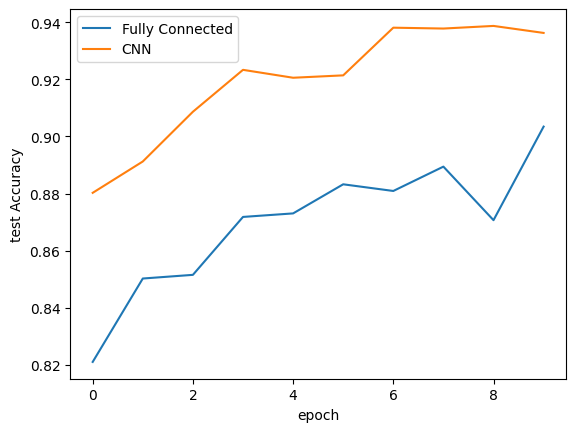

In [13]:
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results, label='Fully Connected')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results, label='CNN')

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6864/3333455690.py:9: SyntaxWarning: invalid escape sequence '\s'
  sns.lineplot(x=activation_input, y=sigmoid_activation, color='blue', label="$\sigma(x)$")


<Axes: >

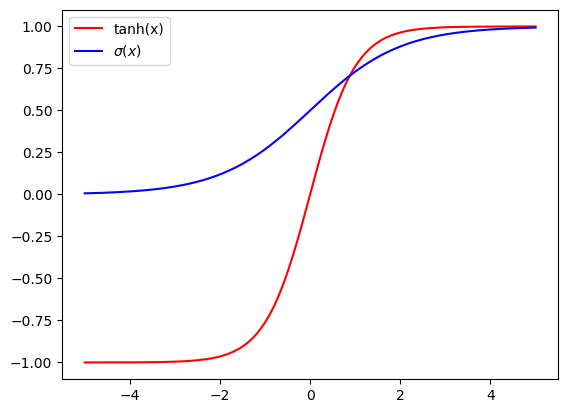

In [14]:
def sigmoid(x):
    return np.exp(activation_input)/(np.exp(activation_input)+1)

activation_input = np.linspace(-5, 5, num=200)
tanh_activation = np.tanh(activation_input)
sigmoid_activation = sigmoid(activation_input)

sns.lineplot(x=activation_input, y=tanh_activation, color='red', label="tanh(x)")
sns.lineplot(x=activation_input, y=sigmoid_activation, color='blue', label="$\sigma(x)$")

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6864/3885070753.py:10: SyntaxWarning: invalid escape sequence '\s'
  sns.lineplot(x=activation_input, y=sigmoid_deriv, color='blue', label="$\sigma'(x)$")


<Axes: >

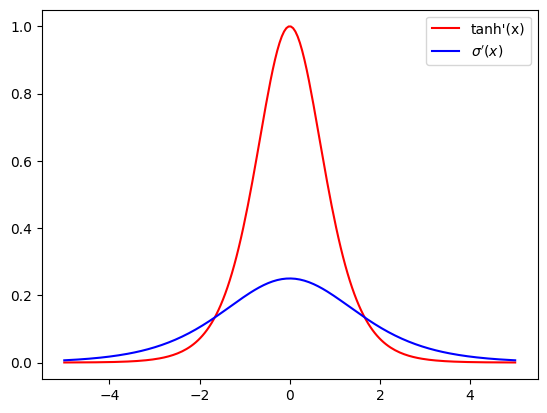

In [15]:
def tanh_deriv(x):
    return 1.0 - np.tanh(x)**2
def sigmoid_derivative(x):
    return sigmoid(x)*(1-sigmoid(x))

tanh_deriv = tanh_deriv(activation_input)
sigmoid_deriv = sigmoid_derivative(activation_input)

sns.lineplot(x=activation_input, y=tanh_deriv, color='red', label="tanh'(x)")
sns.lineplot(x=activation_input, y=sigmoid_deriv, color='blue', label="$\sigma'(x)$")

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6864/3653349960.py:6: SyntaxWarning: invalid escape sequence '\s'
  sns.lineplot(x=activation_input, y=sigmoid_activation, color='blue', label="$\sigma(x)$")


<Axes: >

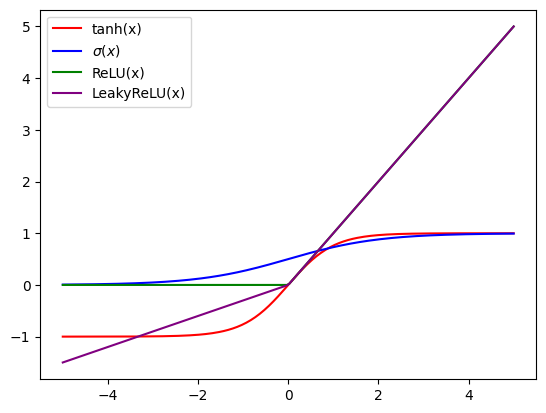

In [16]:
activation_input = np.linspace(-5, 5, num=200)
relu_activation = np.maximum(0,activation_input)
leaky_relu_activation = np.maximum(0.3*activation_input,activation_input)

sns.lineplot(x=activation_input, y=tanh_activation, color='red', label="tanh(x)")
sns.lineplot(x=activation_input, y=sigmoid_activation, color='blue', label="$\sigma(x)$")
sns.lineplot(x=activation_input, y=relu_activation, color='green', label="ReLU(x)")
sns.lineplot(x=activation_input, y=leaky_relu_activation, color='purple', label="LeakyReLU(x)")

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6864/379266970.py:5: SyntaxWarning: invalid escape sequence '\s'
  sns.lineplot(x=activation_input, y=sigmoid_deriv, color='blue', label="$\sigma'(x)$")


<Axes: >

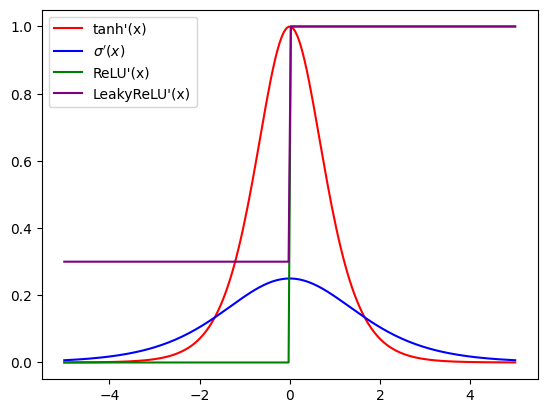

In [17]:
relu_deriv = 1.0*(activation_input > 0)
leaky_deriv = 1.0*(activation_input > 0) + 0.3*(activation_input <= 0)

sns.lineplot(x=activation_input, y=tanh_deriv, color='red', label="tanh'(x)")
sns.lineplot(x=activation_input, y=sigmoid_deriv, color='blue', label="$\sigma'(x)$")
sns.lineplot(x=activation_input, y=relu_deriv, color='green', label="ReLU'(x)")
sns.lineplot(x=activation_input, y=leaky_deriv, color='purple', label="LeakyReLU'(x)")

In [18]:
leak_rate = 0.1 #How much I want the LeakyReLU to "leak" by. Anything in [0.01, 0.3] would have been fine.

In [19]:
fc_relu_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D,  n), nn.LeakyReLU(leak_rate),
    *[nn.Sequential(nn.Linear(n,  n), nn.LeakyReLU(leak_rate)) for _ in range(5)],
    nn.Linear(n, classes),
)

In [20]:
def cnnLayer(in_filters, out_filters=None, kernel_size=3):
    """
    in_filters: how many channels are coming into the layer
    out_filters: how many channels this layer should learn / output, or `None` if we want to have the same number of channels as the input.
    kernel_size: how large the kernel should be
    """
    if out_filters is None:
        out_filters = in_filters #This is a common pattern, so lets automate it as a default if not asked
    padding=kernel_size//2 #padding to stay the same size
    return nn.Sequential( # Combine the layer and activation into a single unit
        nn.Conv2d(in_filters, out_filters, kernel_size, padding=padding),
        nn.LeakyReLU(leak_rate)
    )

In [21]:
cnn_relu_model = nn.Sequential(
    cnnLayer(C, n_filters), cnnLayer(n_filters), cnnLayer(n_filters),
    nn.MaxPool2d((2,2)),
    cnnLayer(n_filters, 2*n_filters), cnnLayer(2*n_filters), cnnLayer(2*n_filters),
    nn.MaxPool2d((2,2)),
    cnnLayer(2*n_filters, 4*n_filters), cnnLayer(4*n_filters),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes),
)
#Caption: This is our generic CNN code block. Ignoring the object name, this code block can be re-purposed for many different styles of CNN hidden layers by changing the definition of the cnnLayer function.

In [22]:
fc_relu_results = train_network(fc_relu_model, loss_func, train_loader, test_loader=test_loader, epochs=10, score_funcs={'Accuracy': accuracy_score}, device=device)
del fc_relu_model
cnn_relu_results = train_network(cnn_relu_model, loss_func, train_loader, test_loader=test_loader, epochs=10, score_funcs={'Accuracy': accuracy_score}, device=device)
del cnn_relu_model

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/469 [00:00<?, ?it/s]

Testing:   0%|          | 0/469 [00:00<?, ?it/s]

Training:   0%|          | 0/469 [00:00<?, ?it/s]

Testing:   0%|          | 0/469 [00:00<?, ?it/s]

...

Testing:   0%|          | 0/469 [00:00<?, ?it/s]

Training:   0%|          | 0/469 [00:00<?, ?it/s]

Testing:   0%|          | 0/469 [00:00<?, ?it/s]

Training:   0%|          | 0/469 [00:00<?, ?it/s]

Testing:   0%|          | 0/469 [00:00<?, ?it/s]

<Axes: xlabel='epoch', ylabel='test Accuracy'>

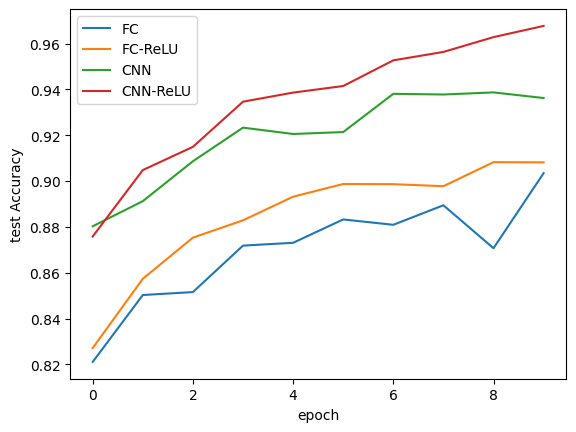

In [23]:
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results, label='FC')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_relu_results, label='FC-ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results, label='CNN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_relu_results, label='CNN-ReLU')

In [24]:
fc_bn_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D,  n), nn.BatchNorm1d(n), nn.LeakyReLU(leak_rate),
    *[nn.Sequential(nn.Linear(n,  n), nn.BatchNorm1d(n), nn.LeakyReLU(leak_rate)) for _ in range(5)],
    nn.Linear(n, classes),
)

In [25]:
def cnnLayer(in_filters, out_filters=None, kernel_size=3):
    if out_filters is None:
        out_filters = in_filters #This is a common pattern, so lets automate it as a default if not asked
    padding=kernel_size//2 #padding to stay the same size
    return nn.Sequential( # Combine the layer and activation into a single unit
        nn.Conv2d(in_filters, out_filters, kernel_size, padding=padding),
        nn.BatchNorm2d(out_filters), #The only change, adding BatchNorm2d after our convolution!
        nn.LeakyReLU(leak_rate)
    )

In [26]:
cnn_bn_model = nn.Sequential(
    cnnLayer(C, n_filters), cnnLayer(n_filters), cnnLayer(n_filters),
    nn.MaxPool2d((2,2)),
    cnnLayer(n_filters, 2*n_filters), cnnLayer(2*n_filters), cnnLayer(2*n_filters),
    nn.MaxPool2d((2,2)),
    cnnLayer(2*n_filters, 4*n_filters), cnnLayer(4*n_filters),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes),
)

In [27]:
fc_bn_results = train_network(fc_bn_model, loss_func, train_loader, test_loader=test_loader, epochs=10, score_funcs={'Accuracy': accuracy_score}, device=device)
del fc_bn_model
cnn_bn_results = train_network(cnn_bn_model, loss_func, train_loader, test_loader=test_loader, epochs=10, score_funcs={'Accuracy': accuracy_score}, device=device)
del cnn_bn_model

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/469 [00:00<?, ?it/s]

Testing:   0%|          | 0/469 [00:00<?, ?it/s]

Training:   0%|          | 0/469 [00:00<?, ?it/s]

Testing:   0%|          | 0/469 [00:00<?, ?it/s]

...

Testing:   0%|          | 0/469 [00:00<?, ?it/s]

Training:   0%|          | 0/469 [00:00<?, ?it/s]

Testing:   0%|          | 0/469 [00:00<?, ?it/s]

Training:   0%|          | 0/469 [00:00<?, ?it/s]

Testing:   0%|          | 0/469 [00:00<?, ?it/s]

<Axes: xlabel='epoch', ylabel='test Accuracy'>

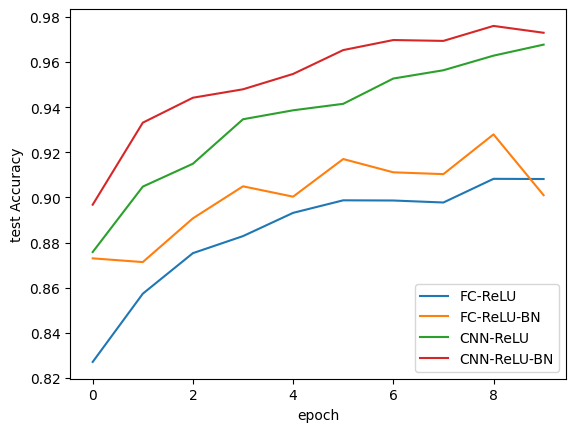

In [28]:
sns.lineplot(x='epoch', y='test Accuracy', data=fc_relu_results, label='FC-ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_bn_results, label='FC-ReLU-BN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_relu_results, label='CNN-ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_bn_results, label='CNN-ReLU-BN')

In [29]:
fc_ln_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D,  n), nn.LayerNorm([n]), nn.LeakyReLU(leak_rate),
    *[nn.Sequential(nn.Linear(n,  n), nn.LayerNorm([n]), nn.LeakyReLU(leak_rate)) for _ in range(5)],
    nn.Linear(n, classes),
)

In [30]:
def cnnLayer(in_filters, out_filters=None, pool_factor=0,kernel_size=3):
    if out_filters is None:
        out_filters = in_filters #This is a common pattern, so lets automate it as a default if not asked
    padding=kernel_size//2 #padding to stay the same size
    return nn.Sequential( # Combine the layer and activation into a single unit
        nn.Conv2d(in_filters, out_filters, kernel_size, padding=padding),
        nn.LayerNorm([out_filters, W//(2**pool_factor), H//(2**pool_factor)]), #The only change, adding BatchNorm2d after our convolution!
        nn.LeakyReLU(leak_rate)
    )

In [31]:
cnn_ln_model = nn.Sequential(
    cnnLayer(C, n_filters),
    cnnLayer(n_filters),
    cnnLayer(n_filters),
    nn.MaxPool2d((2,2)), #we've done one round of pooling, so , pool_factor=1 now
    cnnLayer(n_filters, 2*n_filters, pool_factor=1),
    cnnLayer(2*n_filters, pool_factor=1),
    cnnLayer(2*n_filters, pool_factor=1),
    nn.MaxPool2d((2,2)), #now we've done two rounds of pooling, so pool_factor=2
    cnnLayer(2*n_filters, 4*n_filters, pool_factor=2),
    cnnLayer(4*n_filters, pool_factor=2),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes),
)

In [32]:
fc_ln_results = train_network(fc_ln_model, loss_func, train_loader, test_loader=test_loader, epochs=10, score_funcs={'Accuracy': accuracy_score}, device=device)
del fc_ln_model
cnn_ln_results = train_network(cnn_ln_model, loss_func, train_loader, test_loader=test_loader, epochs=10, score_funcs={'Accuracy': accuracy_score}, device=device)
del cnn_ln_model

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/469 [00:00<?, ?it/s]

Testing:   0%|          | 0/469 [00:00<?, ?it/s]

Training:   0%|          | 0/469 [00:00<?, ?it/s]

Testing:   0%|          | 0/469 [00:00<?, ?it/s]

...

Testing:   0%|          | 0/469 [00:00<?, ?it/s]

Training:   0%|          | 0/469 [00:00<?, ?it/s]

Testing:   0%|          | 0/469 [00:00<?, ?it/s]

Training:   0%|          | 0/469 [00:00<?, ?it/s]

Testing:   0%|          | 0/469 [00:00<?, ?it/s]

<Axes: xlabel='epoch', ylabel='test Accuracy'>

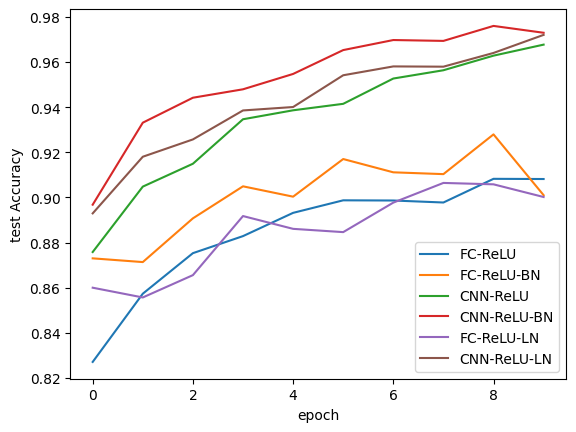

In [33]:
sns.lineplot(x='epoch', y='test Accuracy', data=fc_relu_results, label='FC-ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_bn_results, label='FC-ReLU-BN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_relu_results, label='CNN-ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_bn_results, label='CNN-ReLU-BN')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_ln_results, label='FC-ReLU-LN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_ln_results, label='CNN-ReLU-LN')